In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
prices_day_1_df = pd.read_csv('prices_round_0_day_-2.csv', sep=';')
trades_day_1_df = pd.read_csv('trades_round_0_day_-2.csv', sep=';')
prices_day_2_df = pd.read_csv('prices_round_0_day_-1.csv', sep=';')
trades_day_2_df = pd.read_csv('trades_round_0_day_-1.csv', sep=';')




In [3]:
print("Prices Keys:")
print(prices_day_1_df.keys())
print()

print("Trades Keys:")
print(trades_day_1_df.keys())
print()


Prices Keys:
Index(['day', 'timestamp', 'product', 'bid_price_1', 'bid_volume_1',
       'bid_price_2', 'bid_volume_2', 'bid_price_3', 'bid_volume_3',
       'ask_price_1', 'ask_volume_1', 'ask_price_2', 'ask_volume_2',
       'ask_price_3', 'ask_volume_3', 'mid_price', 'profit_and_loss'],
      dtype='object')

Trades Keys:
Index(['timestamp', 'buyer', 'seller', 'symbol', 'currency', 'price',
       'quantity'],
      dtype='object')



## TOMATOES

In [ ]:
tomatoes_prices_day_1_df = prices_day_1_df[prices_day_1_df['product'] == 'TOMATOES']
tomatoes_trades_day_1_df = trades_day_1_df[trades_day_1_df['symbol'] == 'TOMATOES']
tomatoes_prices_day_2_df = prices_day_2_df[prices_day_2_df['product'] == 'TOMATOES']
tomatoes_trades_day_2_df = trades_day_2_df[trades_day_2_df['symbol'] == 'TOMATOES']

tomatoes_prices_day_1_df



,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
1,-2,0,TOMATOES,4993,7,4992,17,NaN,NaN,5007,7,5008,17,NaN,NaN,5000.0,0.0
2,-2,100,TOMATOES,4998,5,4993,7,4992.0,16.0,5007,7,5008,16,NaN,NaN,5002.5,0.0
4,-2,200,TOMATOES,4994,6,4993,20,NaN,NaN,5008,6,5009,20,NaN,NaN,5001.0,0.0
7,-2,300,TOMATOES,4995,5,4993,21,NaN,NaN,5008,5,5009,21,NaN,NaN,5001.5,0.0
9,-2,400,TOMATOES,4995,8,4993,20,NaN,NaN,5008,8,5009,20,NaN,NaN,5001.5,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19990,-2,999500,TOMATOES,5000,7,4999,20,NaN,NaN,5014,7,5015,20,NaN,NaN,5007.0,0.0
19993,-2,999600,TOMATOES,5000,7,4999,22,NaN,NaN,5014,7,5015,22,NaN,NaN,5007.0,0.0
19994,-2,999700,TOMATOES,4999,10,4998,18,NaN,NaN,5013,10,5014,18,NaN,NaN,5006.0,0.0
19997,-2,999800,TOMATOES,5000,7,4999,24,NaN,NaN,5014,7,5015,24,NaN,NaN,5007.0,0.0


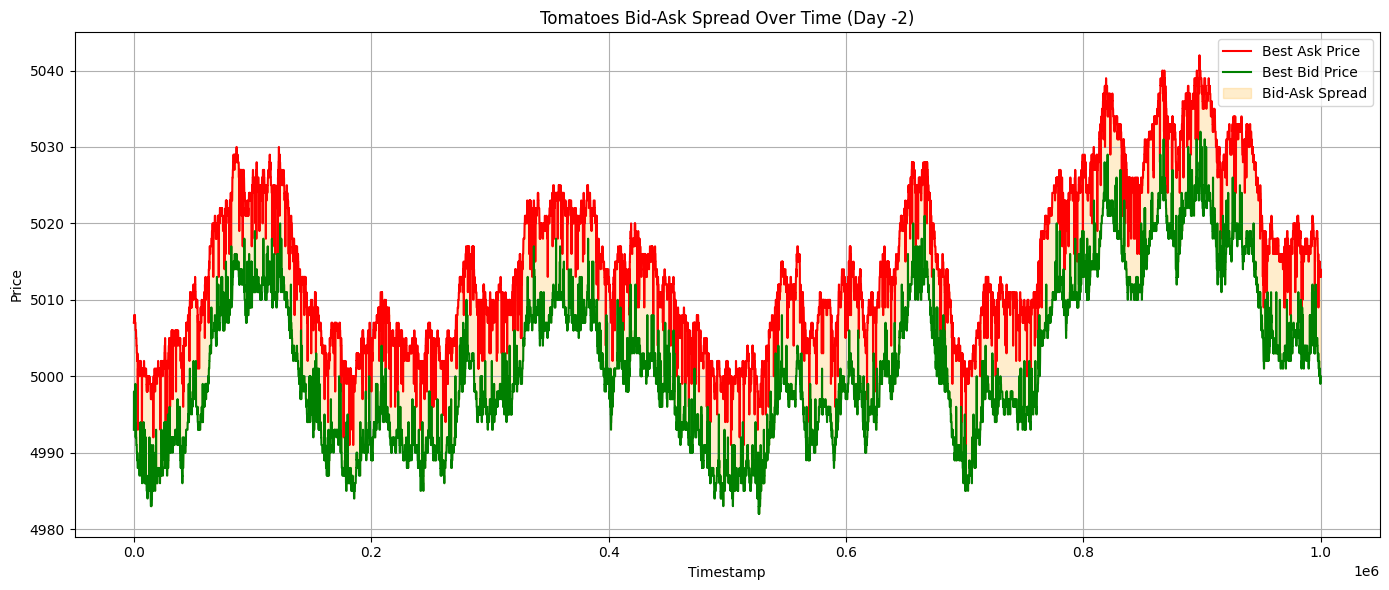

In [22]:
plt.figure(figsize=(14, 6))
plt.plot(tomatoes_prices_day_1_df['timestamp'], tomatoes_prices_day_1_df['ask_price_1'], label='Best Ask Price', color='red', linewidth=1.5)
plt.plot(tomatoes_prices_day_1_df['timestamp'], tomatoes_prices_day_1_df['bid_price_1'], label='Best Bid Price', color='green', linewidth=1.5)

# Plot the bid-ask spread as a filled area
plt.fill_between(
    tomatoes_prices_day_1_df['timestamp'],
    tomatoes_prices_day_1_df['bid_price_1'],
    tomatoes_prices_day_1_df['ask_price_1'],
    color='orange',
    alpha=0.2,
    label='Bid-Ask Spread'
)

plt.title("Tomatoes Bid-Ask Spread Over Time (Day -2)")
plt.xlabel("Timestamp")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()





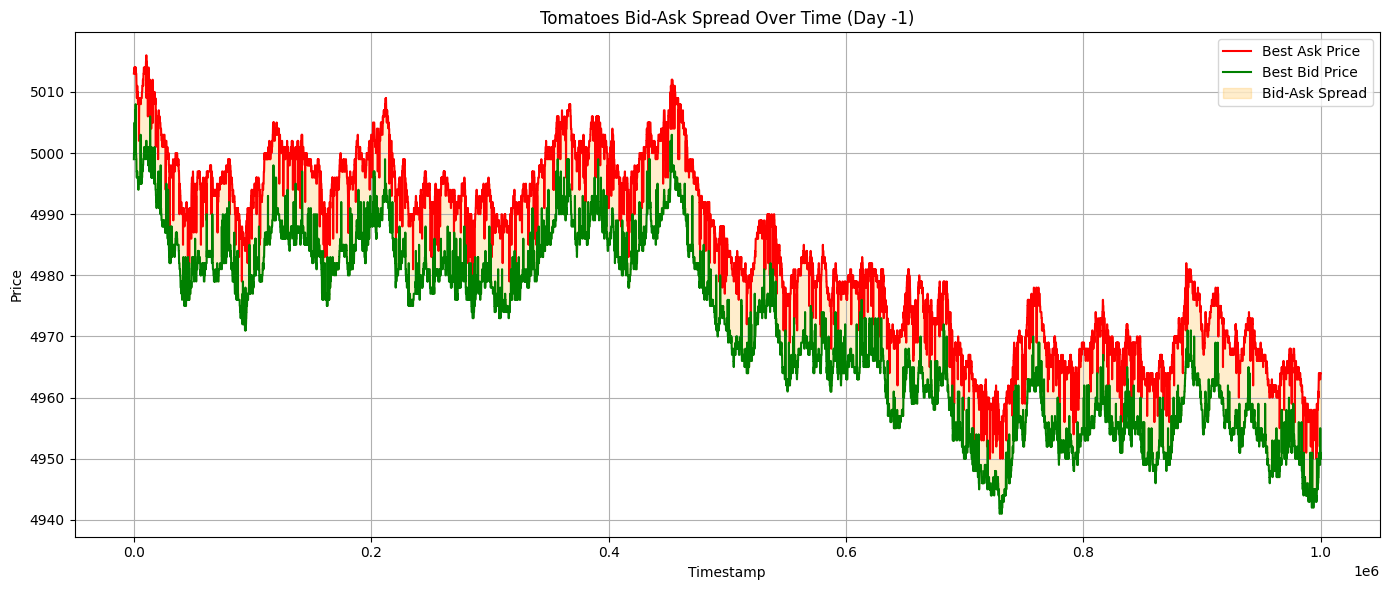

In [14]:
plt.figure(figsize=(14, 6))
plt.plot(tomatoes_prices_day_2_df['timestamp'], tomatoes_prices_day_2_df['ask_price_1'], label='Best Ask Price', color='red', linewidth=1.5)
plt.plot(tomatoes_prices_day_2_df['timestamp'], tomatoes_prices_day_2_df['bid_price_1'], label='Best Bid Price', color='green', linewidth=1.5)

# Plot the bid-ask spread as a filled area
plt.fill_between(
    tomatoes_prices_day_2_df['timestamp'],
    tomatoes_prices_day_2_df['bid_price_1'],
    tomatoes_prices_day_2_df['ask_price_1'],
    color='orange',
    alpha=0.2,
    label='Bid-Ask Spread'
)

plt.title("Tomatoes Bid-Ask Spread Over Time (Day -1)")
plt.xlabel("Timestamp")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()




In [ ]:
tomatoes_prices_day_2_df_shifted = tomatoes_prices_day_2_df.copy()
last_timestamp_day_1 = tomatoes_prices_day_1_df['timestamp'].iloc[-1]
tomatoes_prices_day_2_df_shifted['timestamp'] = tomatoes_prices_day_2_df_shifted['timestamp'] + last_timestamp_day_1 + 100

# Concatenate the two dataframes
tomatoes_combined_df = pd.concat(
    [tomatoes_prices_day_1_df, tomatoes_prices_day_2_df_shifted],
    axis=0,
    ignore_index=True
)

tomatoes_combined_df


,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,-2,0,TOMATOES,4993,7,4992,17,NaN,NaN,5007,7,5008,17,NaN,NaN,5000.0,0.0
1,-2,100,TOMATOES,4998,5,4993,7,4992.0,16.0,5007,7,5008,16,NaN,NaN,5002.5,0.0
2,-2,200,TOMATOES,4994,6,4993,20,NaN,NaN,5008,6,5009,20,NaN,NaN,5001.0,0.0
3,-2,300,TOMATOES,4995,5,4993,21,NaN,NaN,5008,5,5009,21,NaN,NaN,5001.5,0.0
4,-2,400,TOMATOES,4995,8,4993,20,NaN,NaN,5008,8,5009,20,NaN,NaN,5001.5,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,-1,1999500,TOMATOES,4955,5,4950,10,4948.0,23.0,4963,10,4964,23,NaN,NaN,4959.0,0.0
19996,-1,1999600,TOMATOES,4955,5,4949,6,4948.0,18.0,4963,6,4964,18,NaN,NaN,4959.0,0.0
19997,-1,1999700,TOMATOES,4950,10,4948,16,NaN,NaN,4963,10,4964,16,NaN,NaN,4956.5,0.0
19998,-1,1999800,TOMATOES,4951,6,4949,18,NaN,NaN,4964,6,4965,18,NaN,NaN,4957.5,0.0


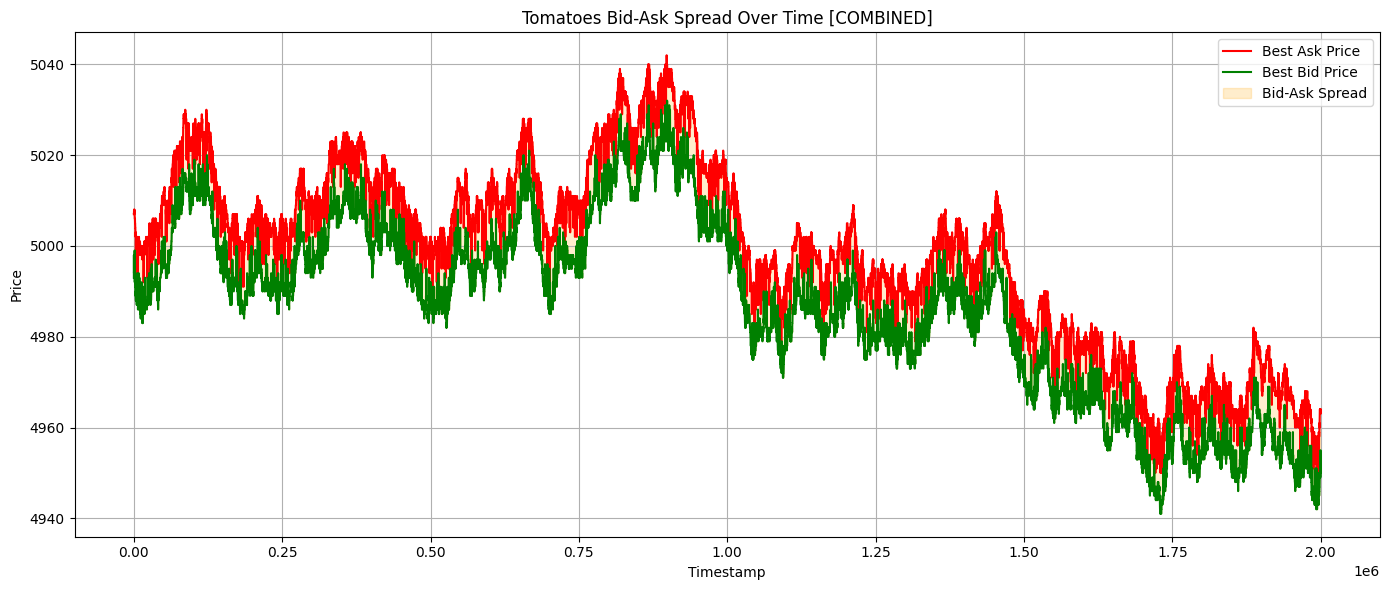

In [15]:
plt.figure(figsize=(14, 6))
plt.plot(tomatoes_combined_df['timestamp'], tomatoes_combined_df['ask_price_1'], label='Best Ask Price', color='red', linewidth=1.5)
plt.plot(tomatoes_combined_df['timestamp'], tomatoes_combined_df['bid_price_1'], label='Best Bid Price', color='green', linewidth=1.5)

# Plot the bid-ask spread as a filled area
plt.fill_between(
    tomatoes_combined_df['timestamp'],
    tomatoes_combined_df['bid_price_1'],
    tomatoes_combined_df['ask_price_1'],
    color='orange',
    alpha=0.2,
    label='Bid-Ask Spread'
)

plt.title("Tomatoes Bid-Ask Spread Over Time [COMBINED]")
plt.xlabel("Timestamp")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()




## EMERALDS

In [27]:
emerald_prices_day_1_df = prices_day_1_df[prices_day_1_df['product'] == 'EMERALDS']
emerald_trades_day_1_df = trades_day_1_df[trades_day_1_df['symbol'] == 'EMERALDS']
emerald_prices_day_2_df = prices_day_2_df[prices_day_2_df['product'] == 'EMERALDS']
emerald_trades_day_2_df = trades_day_2_df[trades_day_2_df['symbol'] == 'EMERALDS']

emerald_prices_day_1_df


,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,-2,0,EMERALDS,9992,11,9990,25,NaN,NaN,10008,11,10010,25,NaN,NaN,10000.0,0.0
3,-2,100,EMERALDS,9992,15,9990,20,NaN,NaN,10008,15,10010,20,NaN,NaN,10000.0,0.0
5,-2,200,EMERALDS,9992,15,9990,30,NaN,NaN,10008,15,10010,30,NaN,NaN,10000.0,0.0
6,-2,300,EMERALDS,9992,13,9990,26,NaN,NaN,10008,13,10010,26,NaN,NaN,10000.0,0.0
8,-2,400,EMERALDS,9992,15,9990,20,NaN,NaN,10008,15,10010,20,NaN,NaN,10000.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19991,-2,999500,EMERALDS,9992,13,9990,24,NaN,NaN,10008,13,10010,24,NaN,NaN,10000.0,0.0
19992,-2,999600,EMERALDS,9992,15,9990,30,NaN,NaN,10008,15,10010,30,NaN,NaN,10000.0,0.0
19995,-2,999700,EMERALDS,9992,10,9990,22,NaN,NaN,10008,10,10010,22,NaN,NaN,10000.0,0.0
19996,-2,999800,EMERALDS,9992,14,9990,25,NaN,NaN,10008,14,10010,25,NaN,NaN,10000.0,0.0


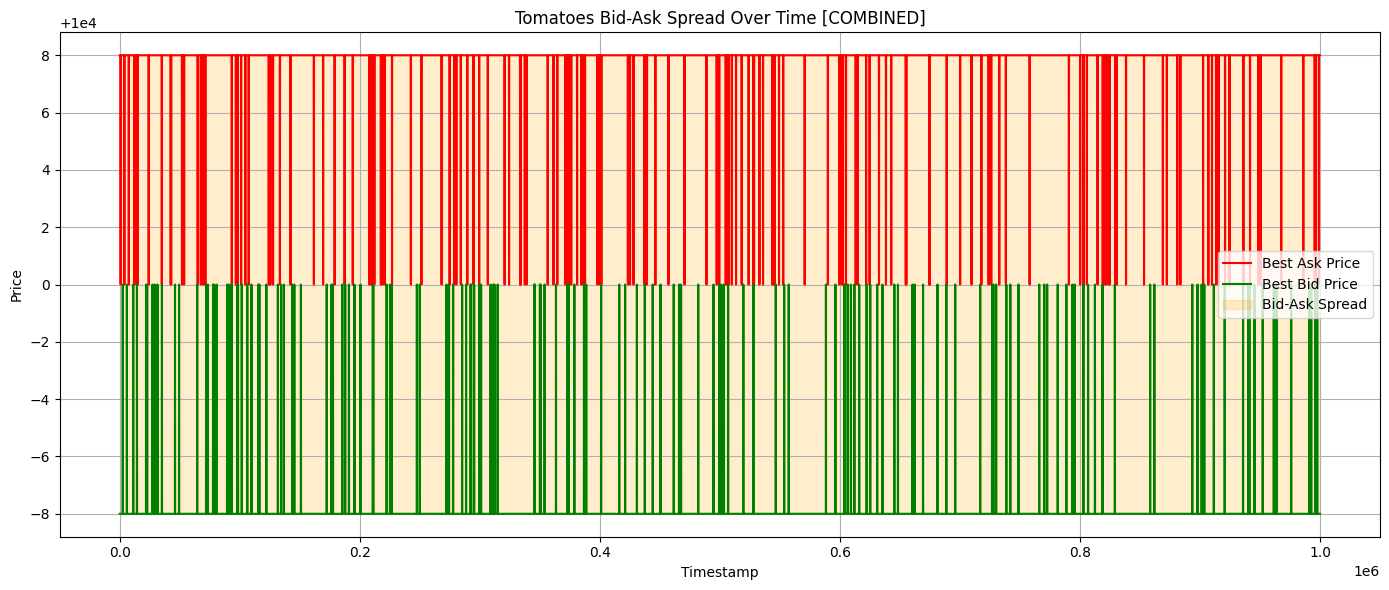

In [ ]:
plt.figure(figsize=(14, 6))
plt.plot(emerald_prices_day_1_df['timestamp'], emerald_prices_day_1_df['ask_price_1'], label='Best Ask Price', color='red', linewidth=1.5)
plt.plot(emerald_prices_day_1_df['timestamp'], emerald_prices_day_1_df['bid_price_1'], label='Best Bid Price', color='green', linewidth=1.5)

# Plot the bid-ask spread as a filled area
plt.fill_between(
    emerald_prices_day_1_df['timestamp'],
    emerald_prices_day_1_df['bid_price_1'],
    emerald_prices_day_1_df['ask_price_1'],
    color='orange',
    alpha=0.2,
    label='Bid-Ask Spread'
)

plt.title("Emeralds Bid-Ask Spread Over Time (Day -2)")
plt.xlabel("Timestamp")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()




In [ ]:
# Print a frequency distribution of bid_price_1 for EMERALDS on day -1
bid_price_counts_1 = emerald_prices_day_1_df['bid_price_1'].value_counts().sort_index()
print("Frequency distribution of Emeralds bid_price_1 (DAY 1):")
print(bid_price_counts_1)
print()

ask_price_counts_1 = emerald_prices_day_1_df['ask_price_1'].value_counts().sort_index()
print("Frequency distribution of Emeralds ask_price_1 (DAY 1):")
print(ask_price_counts_1)
print()

bid_price_counts_2 = emerald_prices_day_2_df['bid_price_1'].value_counts().sort_index()
print("Frequency distribution of Emeralds bid_price_1 (DAY 2):")
print(bid_price_counts_2)
print()

ask_price_counts_2 = emerald_prices_day_2_df['ask_price_1'].value_counts().sort_index()
print("Frequency distribution of Emeralds ask_price_1 (DAY 2):")
print(ask_price_counts_2)
print()


Frequency distribution of Emeralds bid_price_1 (DAY 1):
bid_price_1
9992     9837
10000     163
Name: count, dtype: int64

Frequency distribution of Emeralds ask_price_1 (DAY 1):
ask_price_1
10000     170
10008    9830
Name: count, dtype: int64

Frequency distribution of Emeralds bid_price_1 (DAY 2):
bid_price_1
9992     9842
10000     158
Name: count, dtype: int64

Frequency distribution of Emeralds ask_price_1 (DAY 2):
ask_price_1
10000     163
10008    9837
Name: count, dtype: int64

